In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sns.set_style("whitegrid")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Shankarsingh\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [25]:
us = pd.read_csv("../dataset/US_Trending.csv")
india = pd.read_csv("../dataset/IN_Trending.csv")
uk = pd.read_csv("../dataset/GB_Trending.csv")
canada = pd.read_csv("../dataset/CA_Trending.csv")

In [26]:
us["country"] = "USA"
india["country"] = "India"
uk["country"] = "UK"
canada["country"] = "Canada"

In [27]:
df = pd.concat([us, india, uk, canada])

In [28]:
df.head()

,video_id,trending_date,title,channel_title,views,likes,dislikes,publish_time,category_id,tags,comments,channel_id,description,country
0,5Q_sCOFwC5g,26.26.02,VonOff 1700 - I Tried ft BigOpp (Official Video),VonOff1700,63098,4695,0,2026-02-26T01:00:00Z,10,[none],289,UC023sB-A8vI7F3ByKMF9BGA,Follow on Socials ‼️ Instagram - https://www.i...,USA
1,b24oG7qCwp4,26.26.02,Mortal Kombat II | Official Trailer II,Warner Bros.,3779274,100768,0,2026-02-25T18:01:17Z,1,2026|Action|Adeline Rudolph|Adventure|Battle|C...,5967,UCjmJDM5pRKbUlVIzDYYWb6g,The wait is almost over! Mortal Kombat II arri...,USA
2,e0ii_btaNWs,26.26.02,🔴LIVE | RV THERE YET NEW MAP w/ Cloakzy & Ging...,TheBurntPeanut,957635,17327,0,2026-02-26T09:00:08Z,20,funny|escape from tarkov|tarkov,110,UCMNEVbszv8ZyvSXoTn3yhpQ,NaN,USA
3,iAtoZar5W58,26.26.02,Aaya Sher - Lyrical | The Paradise | Nani | An...,Saregama Telugu,21184078,834698,0,2026-02-24T14:44:06Z,10,Anirudh Ravichander|The Paradise Theme OST|The...,24871,UC68nKdrLbLL0Vj7ilVkLmmg,"For more latest songs & videos, subscribe 👉 ht...",USA
4,qtZeYpjJHi8,26.26.02,T.I. - “Let ‘Em Know” (Official Trailer) [Dir....,T.I.,97799,3406,0,2026-02-25T19:48:20Z,23,ti|t.i.|t i|tip|ti harris|tip harris|Expeditio...,314,UCsD7zvGKkqB7GvQpygW2few,Aight now back to some important sh*t... ✍🏽 Wr...,USA


In [29]:
df["country"].value_counts()

country
USA       16400
UK        16400
Canada    16200
India     16199
Name: count, dtype: int64

In [30]:
df.isnull().sum()

video_id            0
trending_date       0
title               0
channel_title       3
views               0
likes               0
dislikes            0
publish_time        0
category_id         0
tags                1
comments            0
channel_id          0
description      8904
country             0
dtype: int64

In [31]:
df = df.drop_duplicates()

In [32]:
df["publish_time"] = pd.to_datetime(df["publish_time"])

In [33]:
df["publish_date"] = df["publish_time"].dt.date
df["publish_month"] = df["publish_time"].dt.month

In [34]:
df.head()

,video_id,trending_date,title,channel_title,views,likes,dislikes,publish_time,category_id,tags,comments,channel_id,description,country,publish_date,publish_month
0,5Q_sCOFwC5g,26.26.02,VonOff 1700 - I Tried ft BigOpp (Official Video),VonOff1700,63098,4695,0,2026-02-26 01:00:00+00:00,10,[none],289,UC023sB-A8vI7F3ByKMF9BGA,Follow on Socials ‼️ Instagram - https://www.i...,USA,2026-02-26,2
1,b24oG7qCwp4,26.26.02,Mortal Kombat II | Official Trailer II,Warner Bros.,3779274,100768,0,2026-02-25 18:01:17+00:00,1,2026|Action|Adeline Rudolph|Adventure|Battle|C...,5967,UCjmJDM5pRKbUlVIzDYYWb6g,The wait is almost over! Mortal Kombat II arri...,USA,2026-02-25,2
2,e0ii_btaNWs,26.26.02,🔴LIVE | RV THERE YET NEW MAP w/ Cloakzy & Ging...,TheBurntPeanut,957635,17327,0,2026-02-26 09:00:08+00:00,20,funny|escape from tarkov|tarkov,110,UCMNEVbszv8ZyvSXoTn3yhpQ,NaN,USA,2026-02-26,2
3,iAtoZar5W58,26.26.02,Aaya Sher - Lyrical | The Paradise | Nani | An...,Saregama Telugu,21184078,834698,0,2026-02-24 14:44:06+00:00,10,Anirudh Ravichander|The Paradise Theme OST|The...,24871,UC68nKdrLbLL0Vj7ilVkLmmg,"For more latest songs & videos, subscribe 👉 ht...",USA,2026-02-24,2
4,qtZeYpjJHi8,26.26.02,T.I. - “Let ‘Em Know” (Official Trailer) [Dir....,T.I.,97799,3406,0,2026-02-25 19:48:20+00:00,23,ti|t.i.|t i|tip|ti harris|tip harris|Expeditio...,314,UCsD7zvGKkqB7GvQpygW2few,Aight now back to some important sh*t... ✍🏽 Wr...,USA,2026-02-25,2


In [35]:
df.reset_index(drop=True, inplace=True)

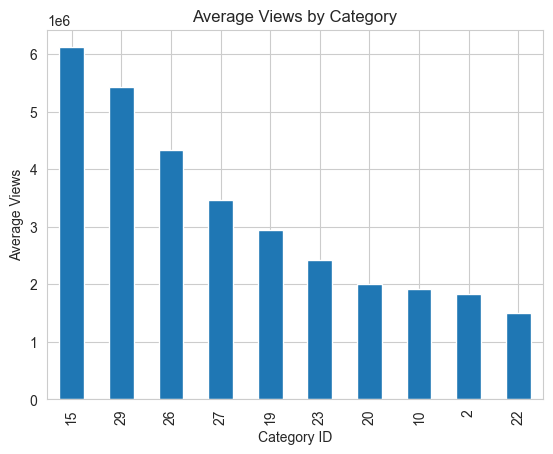

In [36]:
top_categories = df.groupby("category_id")["views"].mean().sort_values(ascending=False)

top_categories.head(10).plot(kind="bar")
plt.title("Average Views by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Views")
plt.savefig("../screenshots/category_views.png")
plt.show()

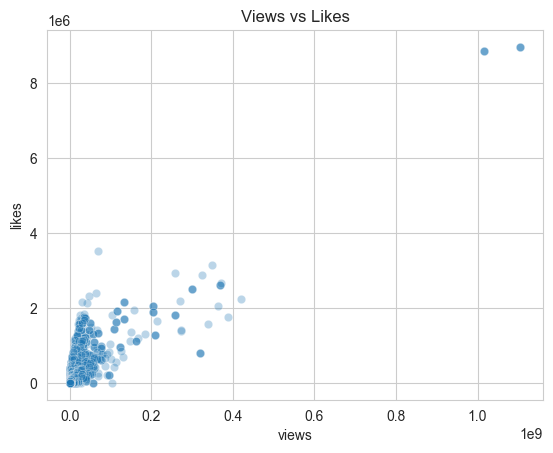

In [37]:
sns.scatterplot(x="views", y="likes", data=df, alpha=0.3)
plt.title("Views vs Likes")

plt.savefig("../screenshots/views_vs_likes.png")
plt.show()

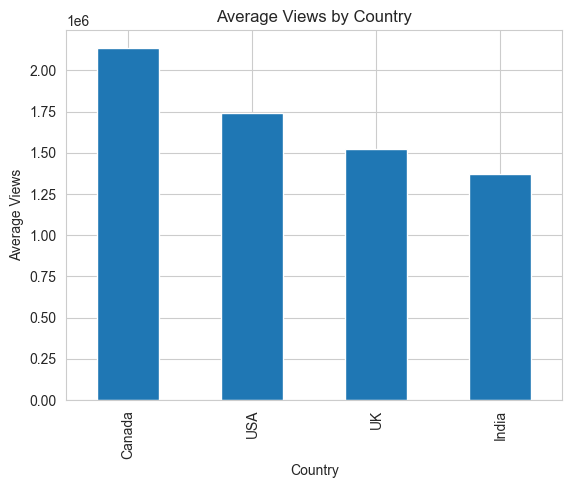

In [38]:
country_views = df.groupby("country")["views"].mean()

country_views.sort_values(ascending=False).plot(kind="bar")
plt.title("Average Views by Country")
plt.xlabel("Country")
plt.ylabel("Average Views")

plt.savefig("../screenshots/country_views.png")
plt.show()

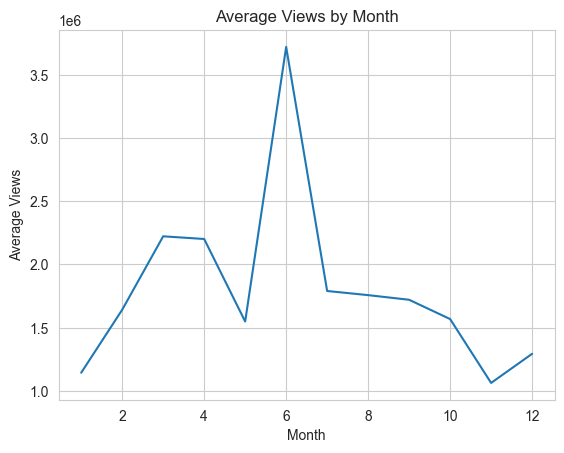

In [39]:
monthly_trend = df.groupby("publish_month")["views"].mean()

monthly_trend.plot(kind="line")
plt.title("Average Views by Month")
plt.xlabel("Month")
plt.ylabel("Average Views")

plt.savefig("../screenshots/monthly_trend.png")
plt.show()

In [40]:
sia = SentimentIntensityAnalyzer()

In [41]:
df["sentiment"] = df["title"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

In [42]:
df["sentiment_type"] = df["sentiment"].apply(
    lambda x: "Positive" if x > 0 else "Negative" if x < 0 else "Neutral"
)

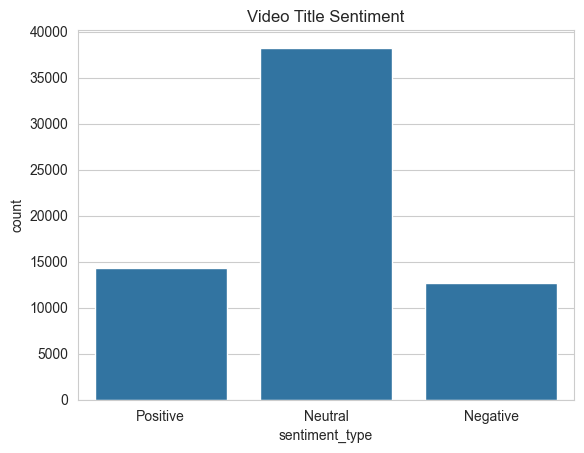

In [43]:
sns.countplot(x="sentiment_type", data=df, order=["Positive", "Neutral", "Negative"])
plt.title("Video Title Sentiment")

plt.savefig("../screenshots/sentiment_distribution.png")
plt.show()

In [44]:
df[["title", "sentiment", "sentiment_type"]].head(10)

,title,sentiment,sentiment_type
0,VonOff 1700 - I Tried ft BigOpp (Official Video),0.0000,Neutral
1,Mortal Kombat II | Official Trailer II,0.0000,Neutral
2,🔴LIVE | RV THERE YET NEW MAP w/ Cloakzy & Ging...,0.0000,Neutral
3,Aaya Sher - Lyrical | The Paradise | Nani | An...,0.6369,Positive
4,T.I. - “Let ‘Em Know” (Official Trailer) [Dir....,0.0000,Neutral
5,Sirius - No more Brawl Stars! (Brawl Stars Ani...,-0.3595,Negative
6,BabyDrill- Knocked Off (Official Music Video),0.0000,Neutral
7,MORTAL KOMBAT 2 Official Trailer 2 (2026),0.0000,Neutral
8,I Moved Into The Wrong Neighborhood…,-0.4767,Negative
9,Pedro Capó & Farruko - Calma (Remix) (Letra),0.0000,Neutral


In [45]:
df.to_csv("../dataset/combined_youtube_data.csv", index=False)